In [12]:
import pickle
import matplotlib.pyplot as plt
import sys

sys.path.append("../")
from train import SimpleCNN

In [13]:
with open("../data/fmnist_28_28.pkl", "rb") as f:
    data = pickle.load(f)

In [3]:
def plot_example(X, y):
    """
    Plot the first 10 images and their labels.
    """
    for i, (img, y) in enumerate(zip(X[:10], y[:10])):
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.xticks([])
        plt.yticks([])
        plt.title(y)

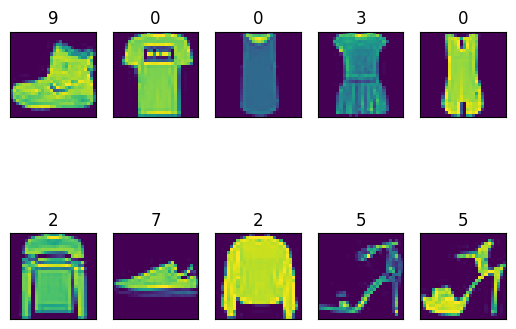

In [4]:
plot_example(data["X_train"], data["y_train"])

In [8]:
def plot_one_example(X, y):
    """
    Plot the first image and its label.
    """
    plt.imshow(X[0])
    plt.xticks([])
    plt.yticks([])

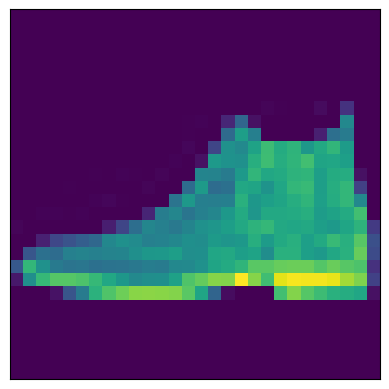

In [9]:
plot_one_example(data["X_test"], data["y_test"])

## Visualizing what convolution does (chosen example + extra conv blocks)

This section shows:
- one chosen test image,
- the learned first-layer kernels,
- how the image is transformed through each CNN block (`Conv -> ReLU -> MaxPool -> Dropout`),
- and a small multi-example view to compare behavior across the dataset.

In [22]:
import os
import math
import re
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt


def infer_cnn_hparams_from_state_dict(state_dict):
    conv_keys = [
        k
        for k, v in state_dict.items()
        if re.match(r"cnn\.\d+\.weight", k) and v.ndim == 4
    ]
    conv_indices = sorted(int(k.split(".")[1]) for k in conv_keys)
    n_layers = len(conv_indices)
    if n_layers == 0:
        raise ValueError("No convolution layers found in checkpoint.")

    first_conv = state_dict[f"cnn.{conv_indices[0]}.weight"]
    input_channels = first_conv.shape[1]
    hidden_dim = first_conv.shape[0]
    output_dim = state_dict["linear.weight"].shape[0]

    return {
        "input_channels": input_channels,
        "hidden_dim": hidden_dim,
        "n_layers": n_layers,
        "output_dim": output_dim,
    }


def load_cnn_from_checkpoint(checkpoint_path):
    state_dict = torch.load(checkpoint_path, map_location="cpu")
    hparams = infer_cnn_hparams_from_state_dict(state_dict)

    # Dropout value does not affect inference-time activations in eval mode.
    model = SimpleCNN(
        input_channels=hparams["input_channels"],
        hidden_dim=hparams["hidden_dim"],
        n_layers=hparams["n_layers"],
        output_dim=hparams["output_dim"],
        dropout=0.0,
    )
    model.load_state_dict(state_dict)
    model.eval()
    return model, hparams


def as_image_tensor(img_2d):
    return torch.tensor(img_2d, dtype=torch.float32).unsqueeze(0).unsqueeze(0)


def forward_blockwise(model, x):
    outputs = []
    n_blocks = len(model.cnn) // 4
    i = 0
    for block_idx in range(n_blocks):
        conv = model.cnn[i]
        relu = model.cnn[i + 1]
        pool = model.cnn[i + 2]
        drop = model.cnn[i + 3]

        x_conv = conv(x)
        x_relu = relu(x_conv)
        x_pool = pool(x_relu)
        x = drop(x_pool)

        outputs.append(
            {
                "block": block_idx + 1,
                "conv": x_conv.detach().cpu(),
                "relu": x_relu.detach().cpu(),
                "pool": x_pool.detach().cpu(),
                "after_block": x.detach().cpu(),
            }
        )
        i += 4
    return outputs


def show_feature_grid(feature_tensor, title, max_channels=12, cmap="magma"):
    # feature_tensor expected shape: [1, C, H, W]
    c = feature_tensor.shape[1]
    n = min(c, max_channels)
    cols = min(6, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.2 * rows))
    axes = np.array(axes).reshape(-1)

    for ch in range(n):
        axes[ch].imshow(feature_tensor[0, ch], cmap=cmap)
        axes[ch].set_title(f"ch {ch}")
        axes[ch].axis("off")

    for idx in range(n, len(axes)):
        axes[idx].axis("off")

    fig.suptitle(title)
    plt.tight_layout()


label_names_fmnist = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]


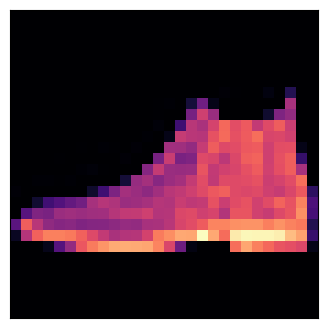

Image shape: (28, 28)


In [31]:
# Pick the example you want to inspect
EXAMPLE_IDX = 0
split_name = "X_test"
label_split = "y_test"

x_img = data[split_name][EXAMPLE_IDX]
y_lbl = int(data[label_split][EXAMPLE_IDX])

plt.figure(figsize=(4, 4))
plt.imshow(x_img, cmap="magma")
# plt.title(
#     f"Chosen example: idx={EXAMPLE_IDX}, label={y_lbl} ({label_names_fmnist[y_lbl]})"
# )
plt.xticks([])
plt.yticks([])
plt.show()

print(f"Image shape: {x_img.shape}")

Available CNN checkpoints (sorted by conv blocks):
  blocks=1, hidden_dim=64, best=True, path=../checkpoints/cnn_experiment/best_checkpoint.pt
  blocks=1, hidden_dim=64, best=True, path=../checkpoints/cnn_hpo/best_checkpoint.pt
  blocks=1, hidden_dim=64, best=False, path=../checkpoints/cnn_experiment/epoch_10.pt
  blocks=1, hidden_dim=64, best=False, path=../checkpoints/cnn_experiment/epoch_2.pt
  blocks=1, hidden_dim=64, best=False, path=../checkpoints/cnn_experiment/epoch_4.pt
  blocks=1, hidden_dim=64, best=False, path=../checkpoints/cnn_experiment/epoch_6.pt
  blocks=1, hidden_dim=64, best=False, path=../checkpoints/cnn_experiment/epoch_8.pt
  blocks=1, hidden_dim=64, best=False, path=../checkpoints/cnn_hpo/epoch_10.pt
  blocks=1, hidden_dim=64, best=False, path=../checkpoints/cnn_hpo/epoch_2.pt
  blocks=1, hidden_dim=64, best=False, path=../checkpoints/cnn_hpo/epoch_4.pt

Selected checkpoint: ../checkpoints/cnn_experiment/best_checkpoint.pt
Inferred architecture: {'input_channels'

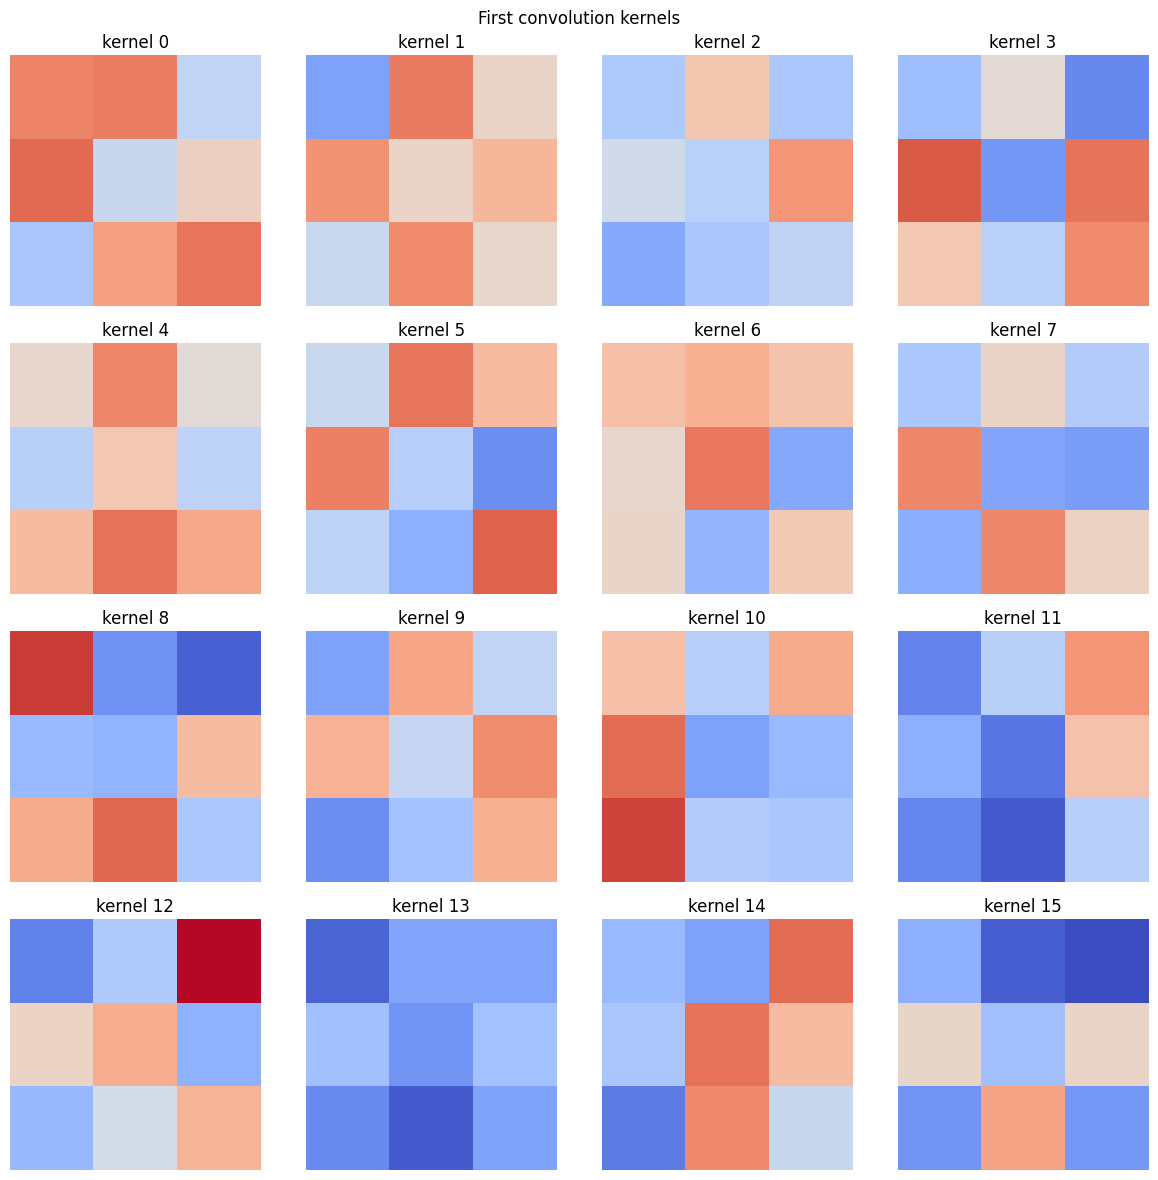

In [25]:
# Find available CNN checkpoints and prefer the one with the most conv blocks.
all_ckpts = sorted(Path("../checkpoints").glob("cnn*/*.pt"))
if not all_ckpts:
    raise FileNotFoundError("No CNN checkpoints found under ../checkpoints.")

checkpoint_info = []
for ckpt in all_ckpts:
    try:
        state = torch.load(ckpt, map_location="cpu")
        hp = infer_cnn_hparams_from_state_dict(state)
        checkpoint_info.append(
            {
                "path": ckpt,
                "n_layers": hp["n_layers"],
                "hidden_dim": hp["hidden_dim"],
                "is_best": ckpt.name == "best_checkpoint.pt",
            }
        )
    except Exception:
        continue

if not checkpoint_info:
    raise RuntimeError("Could not parse any CNN checkpoint.")

checkpoint_info = sorted(
    checkpoint_info,
    key=lambda d: (d["n_layers"], d["is_best"]),
    reverse=True,
)

print("Available CNN checkpoints (sorted by conv blocks):")
for item in checkpoint_info[:10]:
    print(
        f"  blocks={item['n_layers']}, hidden_dim={item['hidden_dim']}, "
        f"best={item['is_best']}, path={item['path']}"
    )

checkpoint_path = checkpoint_info[0]["path"]
model, hparams = load_cnn_from_checkpoint(checkpoint_path)
print(f"\nSelected checkpoint: {checkpoint_path}")
print(f"Inferred architecture: {hparams}")

# Visualize first-layer kernels (what each filter is looking for)
first_conv = next(layer for layer in model.cnn if isinstance(layer, torch.nn.Conv2d))
kernels = first_conv.weight.detach().cpu().numpy()  # [out_ch, in_ch, kH, kW]

n_show = min(16, kernels.shape[0])
cols = 4
rows = math.ceil(n_show / cols)
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = np.array(axes).reshape(-1)

vmax = np.abs(kernels[:n_show, 0]).max()
for i in range(n_show):
    axes[i].imshow(kernels[i, 0], cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axes[i].set_title(f"kernel {i}")
    axes[i].axis("off")

for i in range(n_show, len(axes)):
    axes[i].axis("off")

fig.suptitle("First convolution kernels")
plt.tight_layout()
plt.show()

Number of conv blocks in this checkpoint: 1


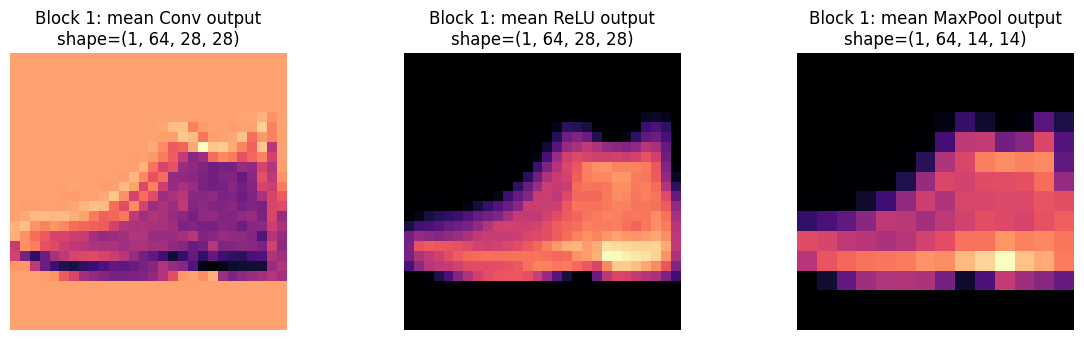

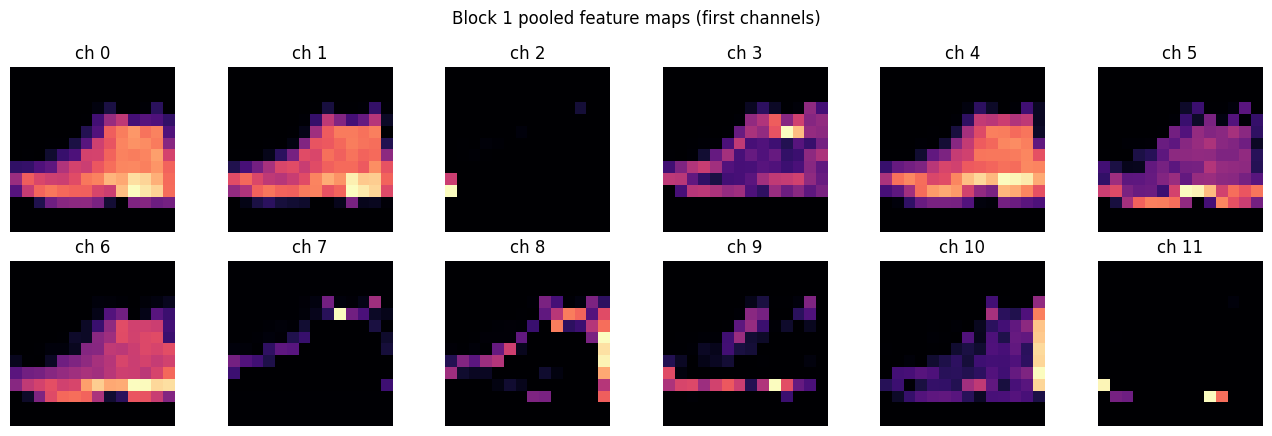

In [26]:
x_tensor = as_image_tensor(x_img)
block_outputs = forward_blockwise(model, x_tensor)

print(f"Number of conv blocks in this checkpoint: {len(block_outputs)}")

for out in block_outputs:
    b = out["block"]
    conv_t = out["conv"]
    relu_t = out["relu"]
    pool_t = out["pool"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    axes[0].imshow(conv_t[0].mean(0), cmap="magma")
    axes[0].set_title(f"Block {b}: mean Conv output\nshape={tuple(conv_t.shape)}")
    axes[0].axis("off")

    axes[1].imshow(relu_t[0].mean(0), cmap="magma")
    axes[1].set_title(f"Block {b}: mean ReLU output\nshape={tuple(relu_t.shape)}")
    axes[1].axis("off")

    axes[2].imshow(pool_t[0].mean(0), cmap="magma")
    axes[2].set_title(f"Block {b}: mean MaxPool output\nshape={tuple(pool_t.shape)}")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    show_feature_grid(
        pool_t, title=f"Block {b} pooled feature maps (first channels)", max_channels=12
    )
    plt.show()

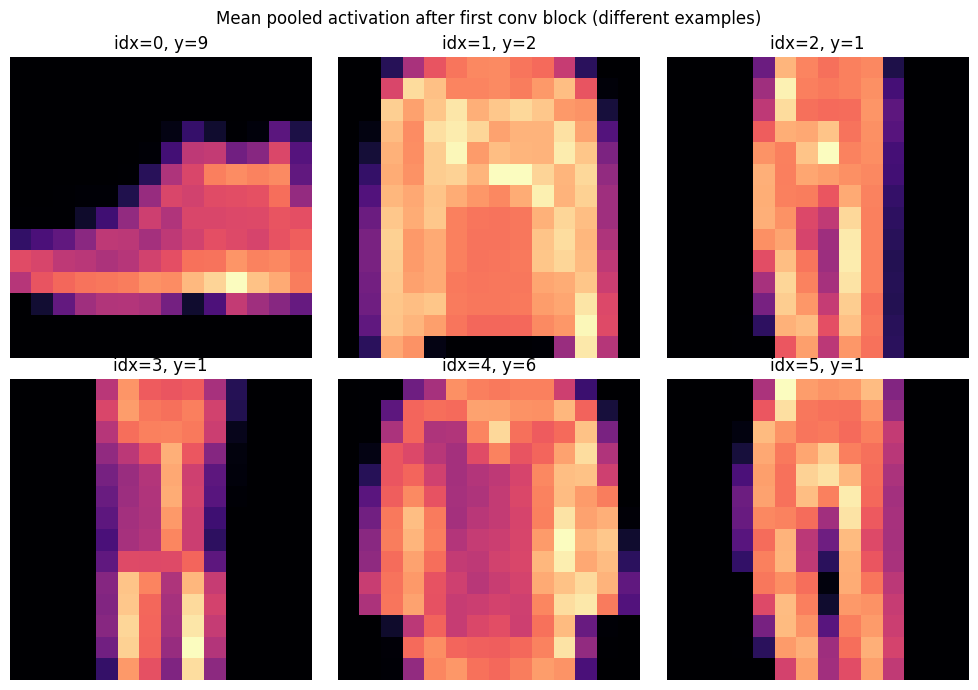

In [27]:
# Dataset-level comparison: same block output for multiple examples
sample_indices = [0, 1, 2, 3, 4, 5]

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
axes = axes.reshape(-1)

for ax, idx in zip(axes, sample_indices):
    img_i = data[split_name][idx]
    y_i = int(data[label_split][idx])
    with torch.no_grad():
        block_out_i = forward_blockwise(model, as_image_tensor(img_i))[0][
            "pool"
        ]  # first block pooled output

    ax.imshow(block_out_i[0].mean(0), cmap="magma")
    ax.set_title(f"idx={idx}, y={y_i}")
    ax.axis("off")

fig.suptitle("Mean pooled activation after first conv block (different examples)")
plt.tight_layout()
plt.show()

In [ ]:
# Save 5 pooled feature maps individually for the chosen example
BLOCK_TO_SAVE = 1  # 1-based block index
CHANNELS_TO_SAVE = [0, 1, 2, 3, 4]
SAVE_DIR = Path("../outputs/feature_maps")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

if "block_outputs" not in globals() or len(block_outputs) < BLOCK_TO_SAVE:
    x_tensor = as_image_tensor(x_img)
    block_outputs = forward_blockwise(model, x_tensor)

pooled = block_outputs[BLOCK_TO_SAVE - 1]["pool"][0]  # shape: [C, H, W]

saved_files = []
for ch in CHANNELS_TO_SAVE:
    if ch >= pooled.shape[0]:
        continue
    out_path = (
        SAVE_DIR / f"example_{EXAMPLE_IDX}_block_{BLOCK_TO_SAVE}_channel_{ch}.png"
    )
    plt.imsave(out_path, pooled[ch].detach().cpu().numpy(), cmap="magma")
    saved_files.append(str(out_path))

print(f"Saved {len(saved_files)} pooled feature maps:")
for p in saved_files:
    print(" -", p)

Saved 5 pooled feature maps:
 - ../outputs/feature_maps/example_0_block_1_channel_0.png
 - ../outputs/feature_maps/example_0_block_1_channel_1.png
 - ../outputs/feature_maps/example_0_block_1_channel_2.png
 - ../outputs/feature_maps/example_0_block_1_channel_3.png
 - ../outputs/feature_maps/example_0_block_1_channel_4.png
